In [2]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path
import os
import pynbody
import pynbody.plot.sph as sph
from IPython.display import clear_output, display
import h5py


from scipy.signal import stft

SMALLSIZE = 12
NORMALSIZE = 12
LARGESIZE = 12

params = {
    "font.family":"serif",
    "mathtext.fontset":"stix",
    "font.size": SMALLSIZE,
    "axes.titlesize" : SMALLSIZE,
    "axes.labelsize" : NORMALSIZE,
    'xtick.labelsize': SMALLSIZE,
    'ytick.labelsize': SMALLSIZE,      
    'legend.fontsize': SMALLSIZE,  
    'figure.titlesize': LARGESIZE,
    'pgf.texsystem' : "pdflatex"
}
matplotlib.rcParams.update(params)

isob_dir = "../data/IsoB_dt10_all"
snap_names = [f"GLX.000{10*(j):03.0f}" for j in range(1, 62)] + [f"GLX.0{10*j:04.0f}" for j in range(62, 101)]
iord_dir  = "../data/fil_iords.csv"

HDF5DIR = "../data/IsoB_faceon.h5"
h5keys = [f"GLX{10*(x+1):04.0f}" for x in range(100)]


['HII', 'HeIII', 'ne', 'hetot', 'hydrogen', 'feh', 'oxh', 'ofe', 'mgfe', 'nefe', 'sife', 'c_s', 'c_s_turb', 'mjeans', 'mjeans_turb', 'ljeans', 'ljeans_turb', 'U_mag', 'U_lum_den', 'B_mag', 'B_lum_den', 'V_mag', 'V_lum_den', 'R_mag', 'R_lum_den', 'I_mag', 'I_lum_den', 'J_mag', 'J_lum_den', 'H_mag', 'H_lum_den', 'K_mag', 'K_lum_den', 'u_mag', 'u_lum_den', 'g_mag', 'g_lum_den', 'r_mag', 'r_lum_den', 'i_mag', 'i_lum_den', 'z_mag', 'z_lum_den', 'y_mag', 'y_lum_den', 'r', 'rxy', 'vr', 'v2', 'vt', 'ke', 'te', 'j', 'j2', 'jz', 'vrxy', 'vcxy', 'vphi', 'vtheta', 'v_mean', 'v_disp', 'v_curl', 'vorticity', 'v_div', 'age', 'theta', 'alt', 'az', 'cs', 'mu', 'p', 'u', 'temp', 'zeldovich_offset', 'aform', 'tform', 'iord_argsort', 'smooth', 'rho', 'u', 'OxMassFrac', '', 'HeI', 'metals', 'HI', 'massform', 'MassHot', 'eps', 'phi', 'Tinc', 'mass', 'timeform', 'tform', 'uHot', 'HeII', 'pos', 'FeMassFrac', 'iord', 'vel', 'igasorder', 'massHot', 'tempEff', 'uDotFB']
1


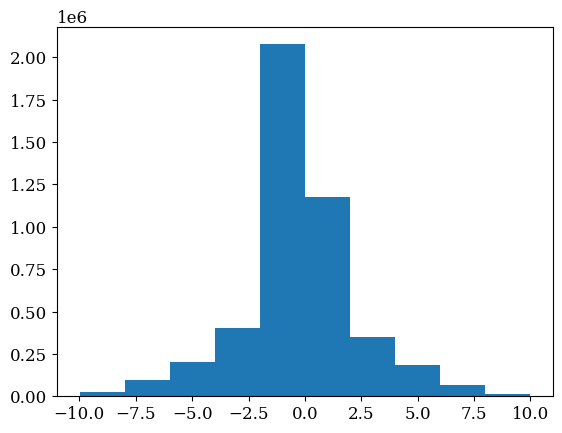

In [19]:
snap = snap_names[99]

sim = pynbody.load(f"{isob_dir}/{snap}")
sim.physical_units()

fig, ax = plt.subplots()
x = sim.s['x']
y = sim.s['y']
r = np.sqrt(x**2 + y**2)

vr = sim.s['vr']

print(sim.s.all_keys())

#im = ax.hist2d(x[r<10],y[r<10],bins=10, norm='log', cmap='inferno')
ax.hist(x[r<10], bins=10)
#fig.colorbar(im[3], ax=ax, label="counts")
print("1")
#pynbody.analysis.angmom.faceon(sim)

In [51]:
all_iords = np.loadtxt("../data/fil_iords.csv")
n_stars = len(all_iords)
timesteps = np.arange(100) * 10 + 10
n_times = len(timesteps)




with h5py.File("../isob10_vr_data.h5", "w") as f_out:
    vr_ds = f_out.create_dataset(
        "vr",
        shape = (n_stars, n_times),
        dtype = np.float32,
        chunks = (50000, 100), 
        compression = 'gzip',
        compression_opts = 4,
        fillvalue = np.nan
    )

    for i, snap_name in enumerate(snap_names):


        sim = pynbody.load(f"{isob_dir}/{snap_name}")
        sim.physical_units()
        pynbody.analysis.angmom.faceon(sim)

        if i < 61:
            iords = sim.s['iord'].astype(np.int64)
        elif i < 95:
            iords = sim.s['iord.txt'].astype(np.int64)
        else:
            iords = sim.s['iord'].astype(np.int64)

        vr = np.array(sim.s['vr'], dtype=np.float32)

        vr_df = pd.DataFrame(dict(
            iord = iords,
            vr = vr
        ))

        vr_sort = vr_df.set_index('iord').reindex(all_iords)['vr'].to_numpy()

        vr_ds[:, i] = vr_sort

        print(f"{i} / 100")


0 / 100
1 / 100
2 / 100
3 / 100
4 / 100
5 / 100
6 / 100
7 / 100
8 / 100
9 / 100
10 / 100
11 / 100
12 / 100
13 / 100
14 / 100
15 / 100
16 / 100
17 / 100
18 / 100
19 / 100
20 / 100
21 / 100
22 / 100
23 / 100
24 / 100
25 / 100
26 / 100
27 / 100
28 / 100
29 / 100
30 / 100
31 / 100
32 / 100
33 / 100
34 / 100
35 / 100
36 / 100
37 / 100
38 / 100
39 / 100
40 / 100
41 / 100
42 / 100
43 / 100
44 / 100
45 / 100
46 / 100
47 / 100
48 / 100
49 / 100
50 / 100
51 / 100
52 / 100
53 / 100
54 / 100
55 / 100
56 / 100
57 / 100
58 / 100
59 / 100
60 / 100
61 / 100
62 / 100
63 / 100
64 / 100
65 / 100
66 / 100
67 / 100
68 / 100
69 / 100
70 / 100
71 / 100
72 / 100
73 / 100
74 / 100
75 / 100
76 / 100
77 / 100
78 / 100
79 / 100
80 / 100
81 / 100
82 / 100
83 / 100
84 / 100
85 / 100
86 / 100
87 / 100
88 / 100
89 / 100
90 / 100
91 / 100
92 / 100
93 / 100
94 / 100
95 / 100
96 / 100
97 / 100
98 / 100
99 / 100


In [70]:
with h5py.File("../isob10_vr_data.h5", "r") as f_out:
    vr = f_out['vr'][:9999, :]

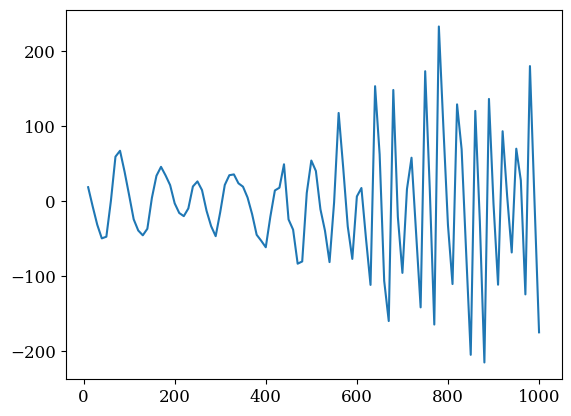

In [75]:
fig, ax = plt.subplots()
t = np.arange(100) * 10 + 10

ax.plot(t, vr[3, :])

In [5]:
with h5py.File("../data/fft_results/isob10_vr_data.h5", "r") as f_vr, h5py.File("../data/isob10_stars.h5") as f_stars:
    print(f_vr['vr'])

<HDF5 dataset "vr": shape (4590904, 100), type "<f4">


[[[-0.34388252 -0.58998774  0.14034678]
  [ 1.03310113 -0.55244027 -0.05233283]
  [ 1.07487712  0.28429997 -0.08610682]
  ...
  [-0.13287274 -0.48590124 -0.20364271]
  [-0.34632408  0.43199396 -0.01573733]
  [ 0.46352639  0.07244515  0.14529256]]

 [[ 1.87902469 -4.53205973  0.31568702]
  [ 3.29158125 -3.46808658  0.25297992]
  [ 4.1472487  -1.76201608 -0.05011934]
  ...
  [-0.99886846 -6.29339656 -0.13691791]
  [ 0.58023329 -6.16412165  0.0794236 ]
  [ 2.10732429 -5.39648744  0.25015055]]

 [[ 1.5230049  -0.81407669 -0.27840361]
  [ 1.55215573 -0.56346097 -0.38806104]
  [ 0.16850868  0.15840155  0.37428881]
  ...
  [-0.99062328  0.79837757  0.25794008]
  [-0.32426747 -0.35145344 -0.13586839]
  [ 1.04199845  0.58780373  0.22779621]]

 ...

 [[-0.3553257   2.65629934 -0.18305768]
  [-1.78581877  1.78795008  0.30462723]
  [-2.25695253  0.02727672  0.1491644 ]
  ...
  [ 1.0448724   1.9677284  -0.25493274]
  [ 0.15718191  3.00731134 -0.335485  ]
  [-0.72947014  2.91720239  0.04332217]]

 [

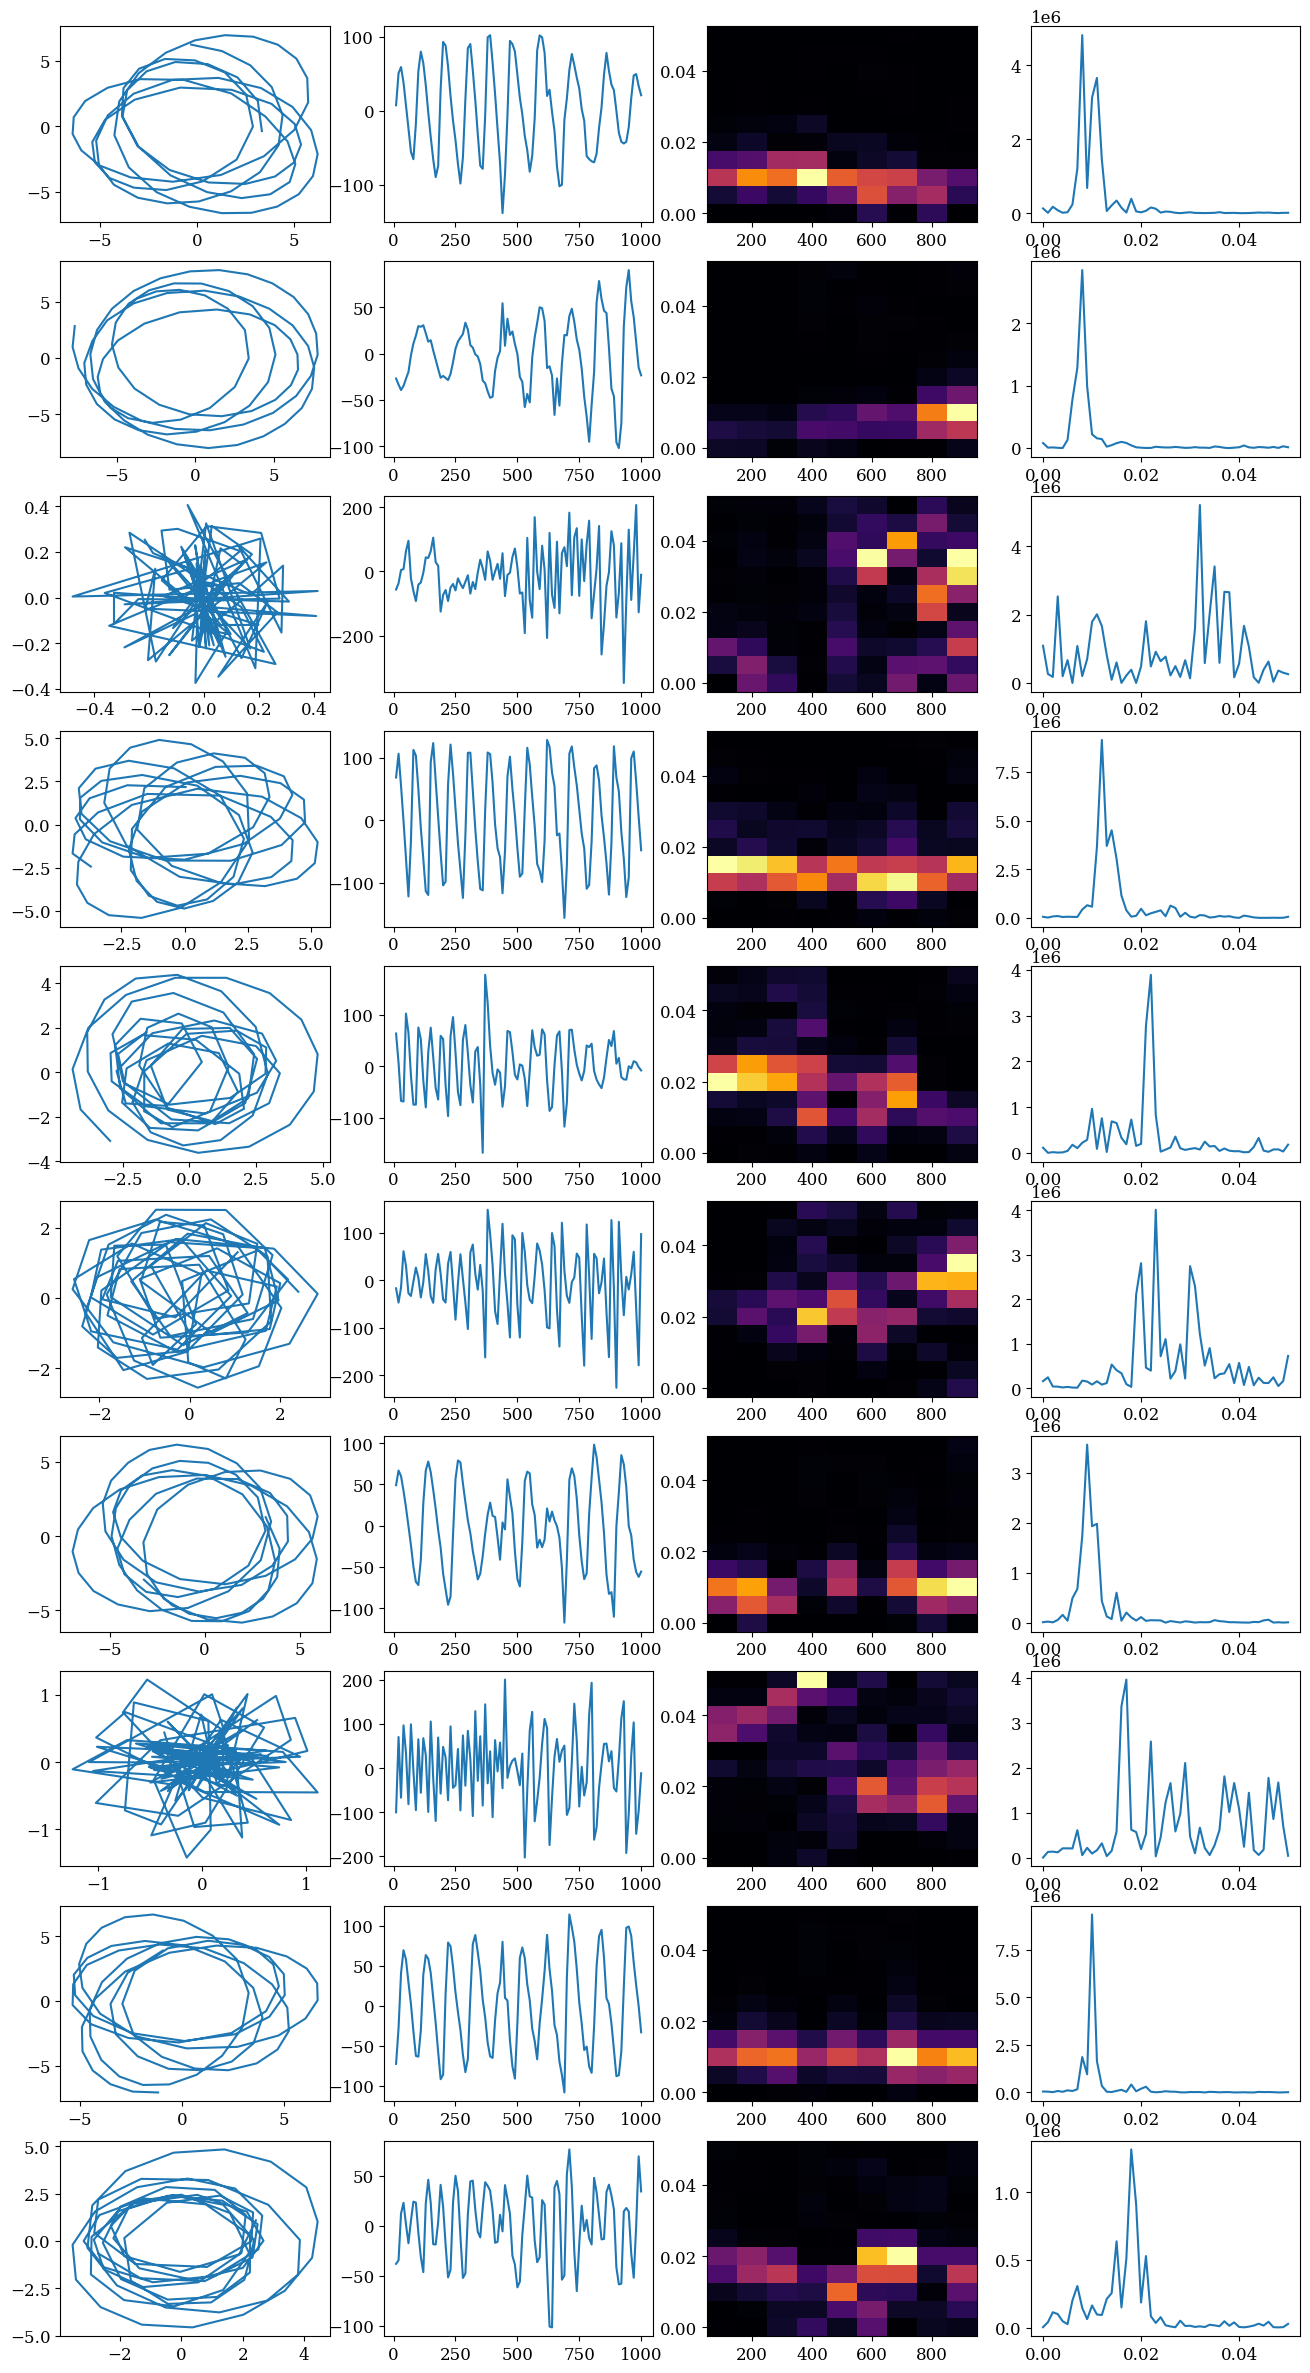

In [25]:
r1, r2 = (0, 1000)

with h5py.File("../isob10_vr_data.h5", "r") as f_vr, h5py.File("../data/isob10_stars.h5") as f_stars:
    vr = f_vr['vr'][r1:r2, :]
    sp = f_stars['trajectories'][r1:r2, :, :]
    print(sp)

fig, axes = plt.subplots(ncols = 4, nrows=10)
fig.set_size_inches(4*4, 3*10)
axes = axes.ravel()

test_range = np.random.randint(0, 1000, 10)

for i in range(10):
    sid = test_range[i]

    freqs, t, zxx = stft(
        vr[sid, :],
        fs = 1/10,
        window = 'hann',
        nperseg=20,
        noverlap=20-10,
        nfft=20,
        boundary = None,
        padded=False,
        axis=-1,
        scaling='psd'
    )

    psd = np.abs(zxx)**2

    vr_data = vr[sid, :]
    vr_data = vr_data[np.isfinite(vr_data)]


    rfft = np.abs(np.fft.rfft(vr_data))**2
    rfft_freq = np.fft.rfftfreq(len(vr_data), d=10)




    print(sp[:, 0])
    ax = axes[4*i]
    ax.plot(sp[sid, :, 0], sp[sid, :, 1])

    ax = axes[4*i + 1]
    ax.plot(np.arange(100)*10 + 10, vr[sid, :])

    ax = axes[4*i + 2]
    ax.pcolormesh(t, freqs, psd, cmap='inferno')

    ax = axes[4*i + 3]
    ax.plot(rfft_freq, rfft)

    print(rfft)